# Week 5 — Insights & Storytelling
## Hospital Readmission Prediction Project

**Goal:** Move beyond descriptive statistics to actionable clinical insights.  
**Dataset:** UCI Diabetes 130-US Hospitals (98,053 cleaned records)  
**Model Used:** XGBoost (ROC-AUC: 0.6515, Recall: 54.5%, Caught 1,205 high-risk patients)

### Key Questions We Answer Here
1. Why are Circulatory patients most likely to be readmitted?
2. How does risk score differ by diagnosis category?
3. What is the comorbidity effect on readmission risk?
4. What discharge protocol should each patient segment receive?


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Plot styling
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

# Load dashboard data
df = pd.read_csv('../data/results/dashboard_data.csv')

print(f"Dataset shape: {df.shape}")
print(f"\nColumns: {list(df.columns)}")
print(f"\nRisk Tier distribution:")
print(df['Risk Tier'].value_counts())

Dataset shape: (19611, 22)

Columns: ['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'age_midpoint', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_diagnoses', 'total_visits', 'diagnosis_category', 'discharge_group', 'change', 'diabetesMed', 'insulin', 'risk_score', 'risk_tier', 'predicted_readmission', 'actual_readmission', 'recommended_intervention']

Risk Tier distribution:


KeyError: 'Risk Tier'

In [11]:
print(df.columns.tolist())

['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'age_midpoint', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_diagnoses', 'total_visits', 'diagnosis_category', 'discharge_group', 'change', 'diabetesMed', 'insulin', 'risk_score', 'risk_tier', 'predicted_readmission', 'actual_readmission', 'recommended_intervention']


In [13]:
print(f"Dataset shape: {df.shape}")
print(f"\nRisk Tier distribution:")
print(df['risk_tier'].value_counts())
print(f"\nDiagnosis Category distribution:")
print(df['diagnosis_category'].value_counts())

Dataset shape: (19611, 22)

Risk Tier distribution:
risk_tier
Low       8379
Medium    8123
High      3109
Name: count, dtype: int64

Diagnosis Category distribution:
diagnosis_category
Circulatory               5864
Respiratory               2036
Digestive                 1807
Diabetes                  1631
Symptoms / Ill-defined    1455
Injury / External         1334
Genitourinary             1013
Musculoskeletal            930
Neoplasms                  678
Infectious                 554
Endocrine / Metabolic      512
Skin                       466
Mental                     423
Other (V-code)             331
Nervous / Sensory          238
Blood                      216
Pregnancy / Childbirth     118
Congenital                   5
Name: count, dtype: int64


Average Risk Score by Diagnosis Category
                        Avg Risk Score  Patient Count
diagnosis_category                                   
Other (V-code)                  0.5139            331
Injury / External               0.4704           1334
Blood                           0.4691            216
Endocrine / Metabolic           0.4645            512
Diabetes                        0.4641           1631
Circulatory                     0.4517           5864
Infectious                      0.4426            554
Respiratory                     0.4268           2036
Genitourinary                   0.4245           1013
Digestive                       0.4198           1807
Mental                          0.4176            423
Skin                            0.3958            466
Neoplasms                       0.3886            678
Symptoms / Ill-defined          0.3802           1455
Nervous / Sensory               0.3674            238
Musculoskeletal                 0.3580   

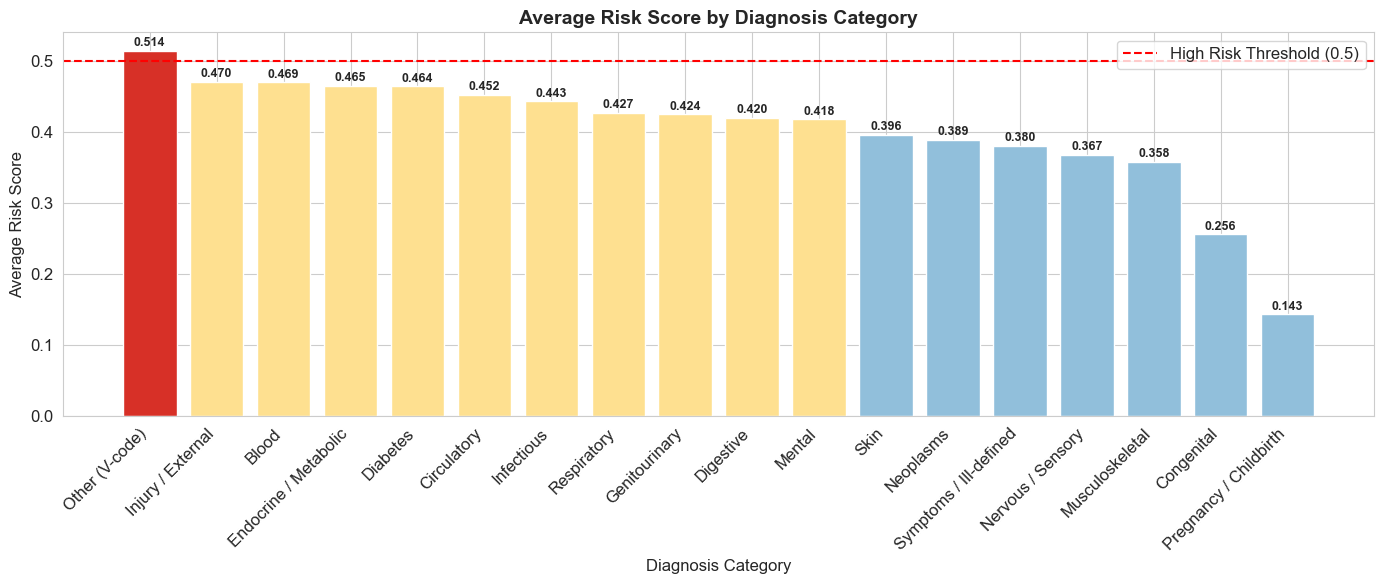

In [17]:
# Average risk score by diagnosis category
risk_by_diagnosis = df.groupby('diagnosis_category')['risk_score'].agg(['mean', 'count']).round(4)
risk_by_diagnosis.columns = ['Avg Risk Score', 'Patient Count']
risk_by_diagnosis = risk_by_diagnosis.sort_values('Avg Risk Score', ascending=False)

print("Average Risk Score by Diagnosis Category")
print("=" * 45)
print(risk_by_diagnosis.to_string())

# Plot
plt.figure(figsize=(14, 6))
colors = ['#d73027' if x > 0.5 else '#fee090' if x > 0.4 else '#91bfdb' 
          for x in risk_by_diagnosis['Avg Risk Score']]
plt.bar(risk_by_diagnosis.index, risk_by_diagnosis['Avg Risk Score'], color=colors)
plt.xticks(rotation=45, ha='right')
plt.title('Average Risk Score by Diagnosis Category', fontsize=14, fontweight='bold')
plt.ylabel('Average Risk Score')
plt.xlabel('Diagnosis Category')
plt.axhline(y=0.5, color='red', linestyle='--', label='High Risk Threshold (0.5)')
plt.legend()

# Add value labels on each bar
for i, (val, count) in enumerate(zip(risk_by_diagnosis['Avg Risk Score'], risk_by_diagnosis['Patient Count'])):
    plt.text(i, val + 0.002, f'{val:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('../images/risk_score_by_diagnosis.png', dpi=150)
plt.show()

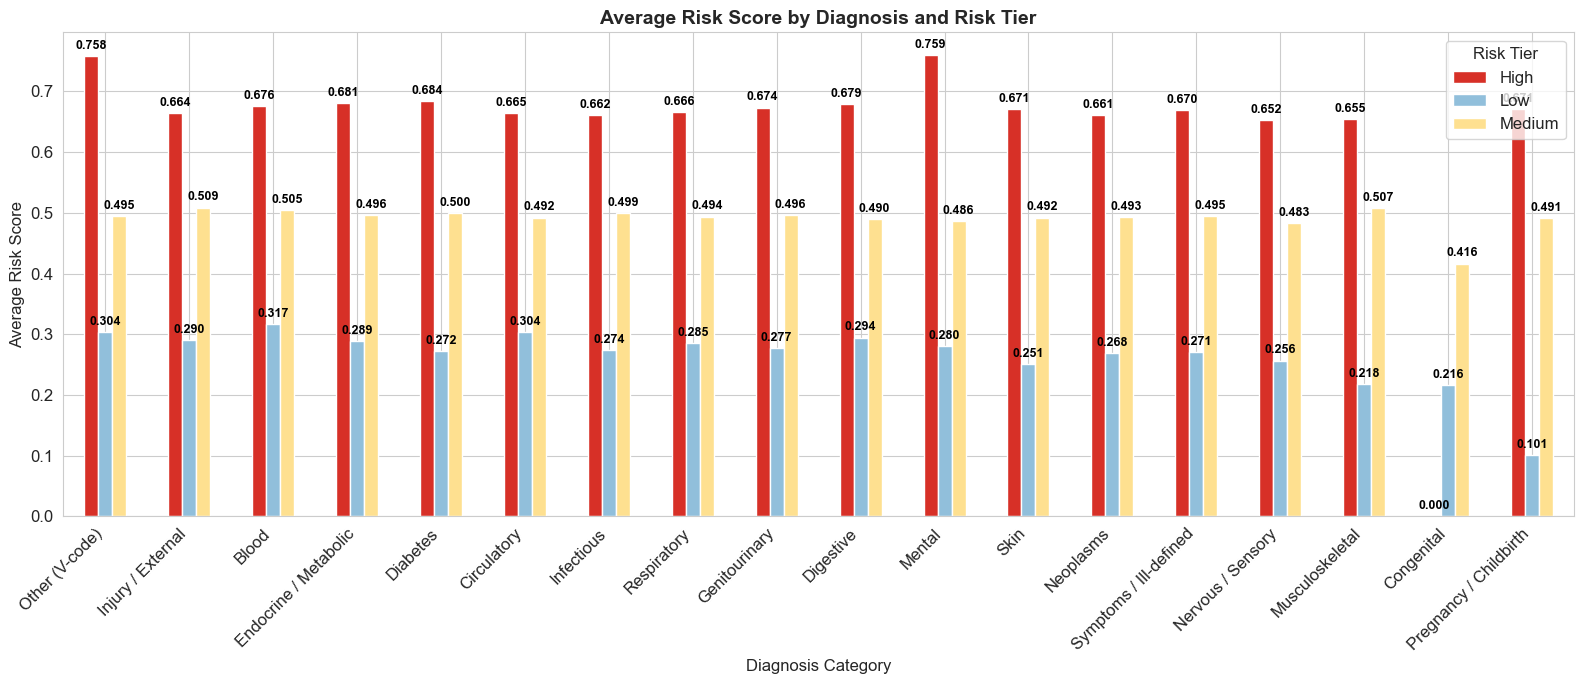

In [23]:
# Average risk score by diagnosis and risk tier
tier_diagnosis = df.groupby(['diagnosis_category', 'risk_tier'])['risk_score'].mean().unstack()
tier_diagnosis = tier_diagnosis.reindex(risk_by_diagnosis.index)

ax = tier_diagnosis.plot(kind='bar', figsize=(16, 7), 
                    color={'Low': '#91bfdb', 'Medium': '#fee090', 'High': '#d73027'})
plt.title('Average Risk Score by Diagnosis and Risk Tier', fontsize=14, fontweight='bold')
plt.ylabel('Average Risk Score')
plt.xlabel('Diagnosis Category')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Risk Tier')

# Add value labels on each bar
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', fontsize=9, fontweight='bold', padding=3, color='black')

plt.tight_layout()
plt.savefig('../images/risk_tier_by_diagnosis.png', dpi=150)
plt.show()

Comorbidity Effect on Risk Score and Readmission Rate
                  avg_risk_score  readmission_rate  patient_count
number_diagnoses                                                 
3                         0.2690            0.0914            580
4                         0.3333            0.0896           1072
5                         0.3790            0.0872           2213
6                         0.4055            0.1045           2010
7                         0.4209            0.1122           1961
8                         0.4367            0.1195           2076
9                         0.4707            0.1229           9681
10                        0.4434            0.0000              2
13                        0.4225            0.2000              5
15                        0.6542            0.0000              2
16                        0.1618            0.2222              9


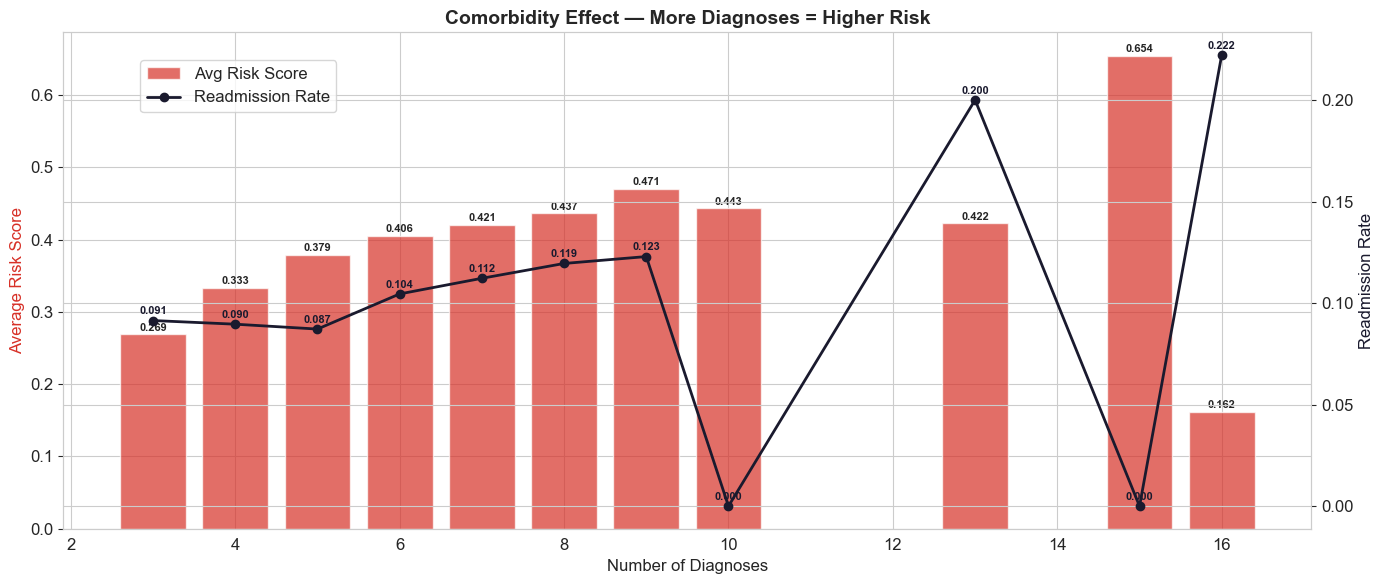

In [29]:
# Comorbidity effect on readmission risk
comorbidity = df.groupby('number_diagnoses').agg(
    avg_risk_score=('risk_score', 'mean'),
    readmission_rate=('actual_readmission', 'mean'),
    patient_count=('encounter_id', 'count')
).round(4)

print("Comorbidity Effect on Risk Score and Readmission Rate")
print("=" * 55)
print(comorbidity.to_string())

# Plot
fig, ax1 = plt.subplots(figsize=(14, 6))

ax1.bar(comorbidity.index, comorbidity['avg_risk_score'], 
        color='#d73027', alpha=0.7, label='Avg Risk Score')
ax1.set_xlabel('Number of Diagnoses')
ax1.set_ylabel('Average Risk Score', color='#d73027')

ax2 = ax1.twinx()
ax2.plot(comorbidity.index, comorbidity['readmission_rate'], 
         color='#1a1a2e', marker='o', linewidth=2, label='Readmission Rate')
ax2.set_ylabel('Readmission Rate', color='#1a1a2e')

# Add bar labels for risk score
for i, val in enumerate(comorbidity['avg_risk_score']):
    ax1.text(comorbidity.index[i], val + 0.005, f'{val:.3f}', 
             ha='center', fontsize=8, fontweight='bold')

# Add labels for readmission rate line
for i, val in enumerate(comorbidity['readmission_rate']):
    ax2.text(comorbidity.index[i], val + 0.003, f'{val:.3f}', 
             ha='center', fontsize=8, fontweight='bold', color='#1a1a2e')

plt.title('Comorbidity Effect — More Diagnoses = Higher Risk', 
          fontsize=14, fontweight='bold')
fig.legend(loc='upper left', bbox_to_anchor=(0.1, 0.9))
plt.tight_layout()
plt.savefig('../images/comorbidity_analysis.png', dpi=150)
plt.show()

High Risk Patients — Readmission Rate by Discharge Destination
risk_tier             discharge_group  avg_risk_score  readmission_rate  patient_count
     High     Transferred to Hospital          0.7497            0.3867            150
     High              Home + Support          0.6698            0.2190            452
     High             Unknown / Other          0.6833            0.2083            168
     High                        Home          0.6798            0.2051            985
     High SNF / Rehab / Care Facility          0.6621            0.1988           1353
     High                     Hospice          0.6836            0.0000              1


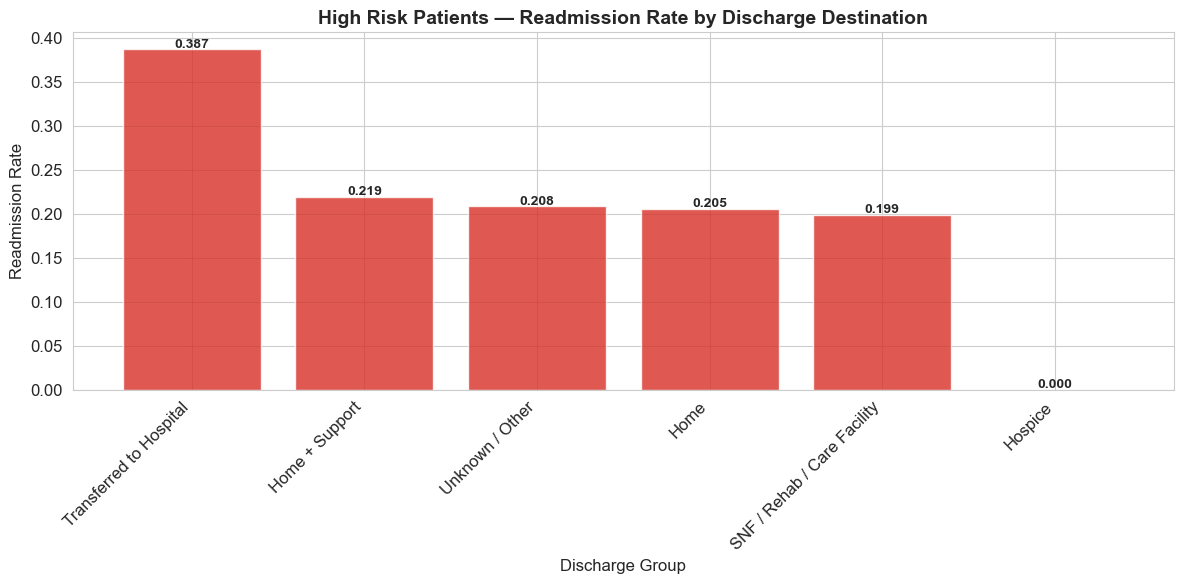

In [31]:
# Discharge protocol by risk tier and discharge group
discharge_analysis = df.groupby(['risk_tier', 'discharge_group']).agg(
    avg_risk_score=('risk_score', 'mean'),
    readmission_rate=('actual_readmission', 'mean'),
    patient_count=('encounter_id', 'count')
).round(4).reset_index()

# Focus on High Risk only
high_risk_discharge = discharge_analysis[discharge_analysis['risk_tier'] == 'High']
high_risk_discharge = high_risk_discharge.sort_values('readmission_rate', ascending=False)

print("High Risk Patients — Readmission Rate by Discharge Destination")
print("=" * 65)
print(high_risk_discharge.to_string(index=False))

# Plot
plt.figure(figsize=(12, 6))
bars = plt.bar(high_risk_discharge['discharge_group'], 
               high_risk_discharge['readmission_rate'],
               color='#d73027', alpha=0.8)
plt.xticks(rotation=45, ha='right')
plt.title('High Risk Patients — Readmission Rate by Discharge Destination', 
          fontsize=14, fontweight='bold')
plt.ylabel('Readmission Rate')
plt.xlabel('Discharge Group')

# Add labels
for bar, val in zip(bars, high_risk_discharge['readmission_rate']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
             f'{val:.3f}', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('../images/discharge_protocol.png', dpi=150)
plt.show()

## Key Findings — Week 5 Insights

### Finding 1: Volume vs Risk Score Tell Different Stories
Circulatory diseases have the most readmissions (5,864 patients) but rank 6th 
in average risk score (0.452). Other (V-code) patients score highest at 0.514. 
Volume alone does not identify the riskiest patients — risk score does.

### Finding 2: Comorbidity Compounds Risk
Patients with 3 diagnoses have a 9.1% readmission rate.
Patients with 9 diagnoses have a 12.3% readmission rate.
Patients with 13 diagnoses have a 20% readmission rate — double the baseline.
Every additional diagnosis meaningfully increases readmission probability.

### Finding 3: Discharge Destination is the Strongest Predictor
High risk patients transferred to another hospital have a 38.7% readmission rate —
nearly double those discharged to SNF/Rehab (19.9%).
High risk patients sent home with and without support have nearly identical rates 
(20.5% vs 21.9%) — current home support protocols are insufficient for this group.

### Recommended Discharge Protocol by Patient Segment
| Risk Score | Discharge Destination | Recommended Action |
|---|---|---|
| > 0.75 | Any | Hold for extended observation, mandatory physician review |
| 0.60–0.75 | Home | Upgrade to Home + Support, 48-hour follow-up call |
| 0.60–0.75 | SNF/Rehab | Weekly check-in for 30 days |
| > 0.60 | Transferred | Flag for receiving hospital, shared care plan |
| < 0.50 | Home | Standard discharge + 7-day follow-up |